In [4]:
# EcoPackAI — Initial Data Exploration (EDA)

# **Module:** Data Exploration & Quality Assessment  
# **Date:** Dec 8  
# **Datasets:**
# - material_dataset_raw.csv
# - product_dataset_raw.csv

# This notebook performs exploratory data analysis (EDA) on raw datasets
# to understand structure, distributions, missing values, duplicates,
# outliers, and overall data quality.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [8]:
materials = pd.read_csv("../data/raw_datasets/material_dataset_raw.csv")
products = pd.read_csv("../data/raw_datasets/product_dataset_raw.csv")


In [9]:
print("Materials shape:", materials.shape)
print("Products shape:", products.shape)

materials.info()
products.info()


Materials shape: (105, 10)
Products shape: (104, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Material ID         105 non-null    int64  
 1   Material Type       105 non-null    object 
 2   IndustryUseCase     105 non-null    object 
 3   Strength(MPa)       94 non-null     float64
 4   Weight Capacity     95 non-null     float64
 5   Biodegradability %  95 non-null     float64
 6   CO2 Emission Score  95 non-null     float64
 7   Recyclability%      95 non-null     float64
 8   Cost/Kg             105 non-null    object 
 9   Upload_Timestamp    105 non-null    object 
dtypes: float64(5), int64(1), object(4)
memory usage: 8.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              -------------- 

In [15]:
materials.head()


,Material ID,Material Type,IndustryUseCase,Strength(MPa),Weight Capacity,Biodegradability %,CO2 Emission Score,Recyclability%,Cost/Kg,Upload_Timestamp
0,31,PLA-GF COMPOSITE,luxury;medical,38.6,NaN,30.0,36.2,88.0,187.18,2025-12-04 01:22:53
1,66,Bamboo Fiber,"automotive,luxury",27.5,75.2,90.0,18.0,52.6,145.03,2025-12-04 02:00:45
2,65,HDPE Plastic,beverages,30.4,25.4,40.0,70.0,43.8,Rs 80,2025-12-04 02:39:53
3,54,Cellulose Film,pharma;toys,43.1,23.7,90.0,82.5,48.6,110.3,2025-12-04 02:16:35
4,46,Hemp Fiber Composite,food;fragile_goods,17.7,16.7,60.0,NaN,78.9,179.97,2025-12-04 01:54:31


In [16]:

products.head()


,product id,Product-Name,Category,product_weight(kg),fragilityIndex,ship_type,is_active
0,10,Laptop,electronics,0.014,4.0,sea,true
1,15,Wine Glass,luxury,0.01,3.0,road,FALSE
2,87,Handcrafted Soap,cosmetics,0.136,9.0,AIR,True
3,39,Protein Powder Box,food,1.319,4.0,road,NaN
4,38,Bluetooth Speaker,household,0.147,NaN,road,FALSE


In [18]:
materials.describe()

,Material ID,Strength(MPa),Weight Capacity,Biodegradability %,CO2 Emission Score,Recyclability%
count,105.000000,94.000000,95.000000,95.000000,95.000000,95.000000
mean,51.257143,28.785106,38.569474,57.157895,54.857895,55.346316
std,29.096996,13.388271,19.665955,32.436949,19.857249,17.243369
min,1.000000,3.000000,5.000000,0.000000,11.200000,15.700000
25%,26.000000,20.000000,25.500000,30.000000,43.250000,43.600000
50%,51.000000,27.900000,36.200000,60.000000,55.700000,54.500000
75%,76.000000,36.950000,50.850000,90.000000,69.400000,68.350000
max,100.000000,60.500000,84.000000,98.000000,101.400000,98.700000


In [20]:
products.describe()

,product id,fragilityIndex
count,104.00000,92.000000
mean,50.37500,4.880435
std,29.08514,2.152649
min,1.00000,1.000000
25%,25.75000,3.000000
50%,49.50000,4.000000
75%,75.25000,7.000000
max,100.00000,10.000000


In [26]:
# Normalize column names (raw datasets may have extra spaces)
materials.columns = materials.columns.str.strip()
products.columns = products.columns.str.strip()

materials["Material Type"].value_counts().head(10)


Material Type
Aluminum Foil              4
Corrugated Cardboard       4
PLA-Coated Paper           3
Nanocellulose Board        3
Mycelium Composite         3
Kraft Paper                3
Recycled Glass             3
Aluminum Composite         3
Starch-Based Biopolymer    3
Glass Composite            3
Name: count, dtype: int64

In [27]:
products["Category"].value_counts()


Category
electronics    20
food           20
cosmetics      19
pharma         11
home_decor     10
apparel        10
household       7
luxury          5
home decor      2
Name: count, dtype: int64

In [28]:
products["ship_type"].value_counts()


ship_type
road     56
air      24
sea      10
AIR       5
ROAD      5
 road     4
Name: count, dtype: int64

In [29]:
missing_materials = materials.isna().sum()
missing_products = products.isna().sum()

missing_materials, missing_products


(Material ID            0
 Material Type          0
 IndustryUseCase        0
 Strength(MPa)         11
 Weight Capacity       10
 Biodegradability %    10
 CO2 Emission Score    10
 Recyclability%        10
 Cost/Kg                0
 Upload_Timestamp       0
 dtype: int64,
 product id             0
 Product-Name           0
 Category               0
 product_weight(kg)    12
 fragilityIndex        12
 ship_type              0
 is_active             31
 dtype: int64)

In [30]:
missing_table = pd.concat(
    [missing_materials, missing_products],
    axis=1,
    keys=["materials", "products"]
)

missing_table.to_csv("../docs/missing_value_table.csv")


In [31]:
materials.duplicated().sum(), products.duplicated().sum()


(0, 0)

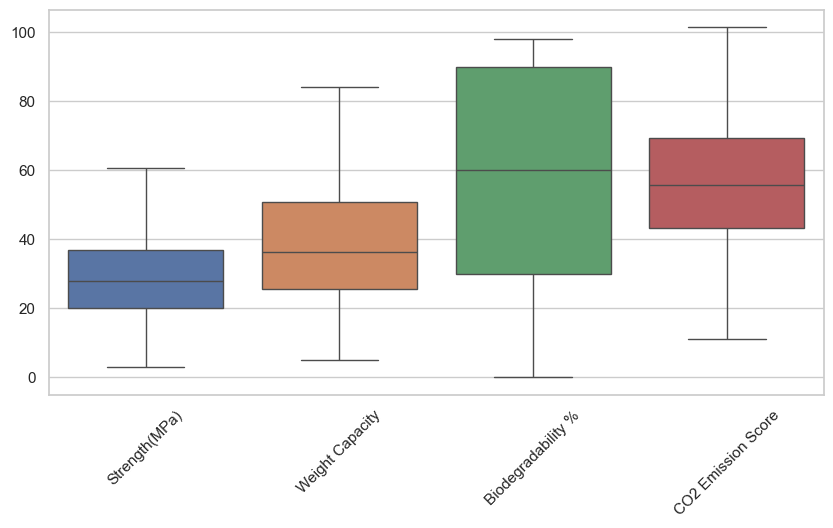

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=materials[[
    "Strength(MPa)",
    "Weight Capacity",
    "Biodegradability %",
    "CO2 Emission Score",
    "Cost/Kg"
]])
plt.xticks(rotation=45)
plt.show()


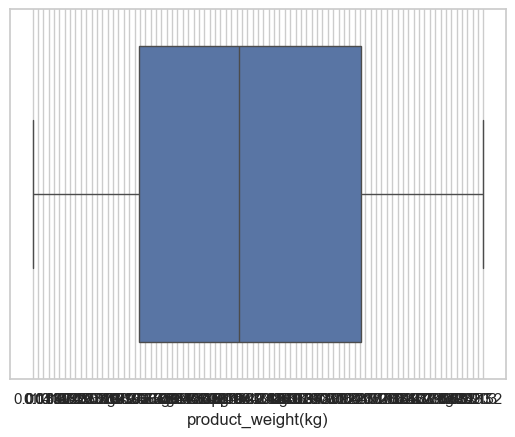

In [35]:
sns.boxplot(x=products["product_weight(kg)"])
plt.show()


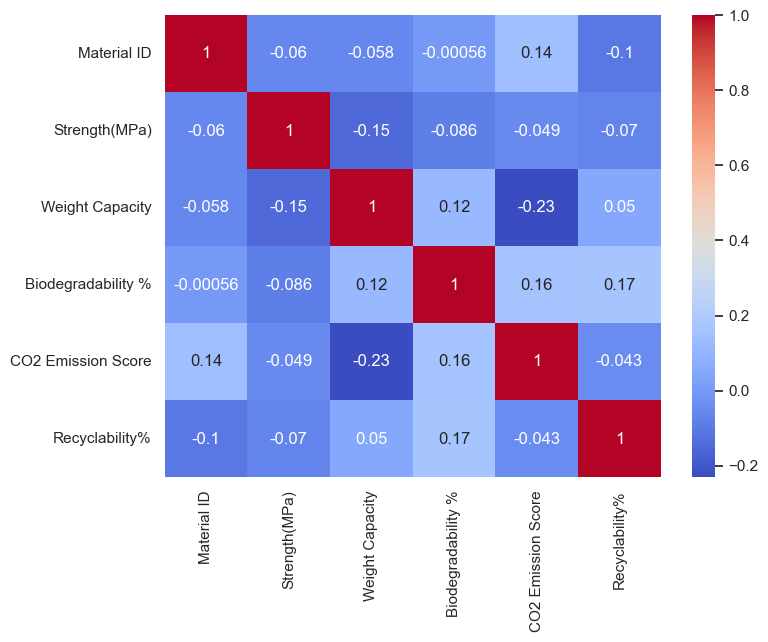

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(materials.select_dtypes(np.number).corr(), annot=True, cmap="coolwarm")
plt.show()


In [37]:
# ## Key Findings

# ### Data Structure
# - Materials dataset contains 105 records; products dataset contains 104 records.
# - Column naming is inconsistent and not snake_case in raw datasets.

# ### Missing Values
# - Raw datasets contain missing values in numerical and categorical fields.
# - Missing values were handled in later cleaning stages using median/mode imputation.

# ### Duplicates
# - No exact duplicate rows detected in raw datasets.

# ### Outliers
# - Outliers observed in cost_per_kg, CO₂ score, and strength.
# - Values remain within realistic domain limits.

# ### Data Quality Concerns
# - Mixed casing and separators in categorical columns.
# - Numeric fields stored as strings with units/currency.
# - 0 biodegradability values may be semantically valid (non-biodegradable materials).

# ### Next Steps
# - Apply systematic cleaning (already completed).
# - Enforce schema constraints at database level.
# - Proceed to feature engineering and ML modeling.
